<a href="https://colab.research.google.com/github/harishscse081sece/DS-project/blob/main/DS_q_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ecommerce_cart_abandonment.csv to ecommerce_cart_abandonment (1).csv


In [ ]:
df = pd.read_csv("ecommerce_cart_abandonment.csv")

df.head()

,Session_ID,Customer_Type,Device,Traffic_Source,Pages_Viewed,Products_Viewed,Cart_Added,Checkout_Started,Purchase,Session_Time,Discount_Shown
0,S00001,New,Mobile,Social,14,14,0,0,0,14.5,No
1,S00002,Returning,Mobile,Organic,7,1,1,1,1,8.8,No
2,S00003,Returning,Mobile,Paid,2,1,1,1,0,11.6,No
3,S00004,returning,Desktop,Social,7,6,1,0,0,14.5,No
4,S00005,New,Mobile,Paid,14,12,1,1,0,16.4,Yes


In [ ]:
print("Shape:", df.shape)

Shape: (10050, 11)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Session_ID        10050 non-null  object 
 1   Customer_Type     10050 non-null  object 
 2   Device            10050 non-null  object 
 3   Traffic_Source    9999 non-null   object 
 4   Pages_Viewed      10050 non-null  int64  
 5   Products_Viewed   10050 non-null  int64  
 6   Cart_Added        10050 non-null  int64  
 7   Checkout_Started  10050 non-null  int64  
 8   Purchase          10050 non-null  int64  
 9   Session_Time      10000 non-null  float64
 10  Discount_Shown    10050 non-null  object 
dtypes: float64(1), int64(5), object(5)
memory usage: 863.8+ KB


In [ ]:
print(df.isnull().sum())

Session_ID           0
Customer_Type        0
Device               0
Traffic_Source      51
Pages_Viewed         0
Products_Viewed      0
Cart_Added           0
Checkout_Started     0
Purchase             0
Session_Time        50
Discount_Shown       0
dtype: int64


In [ ]:
df["Session_Time"] = df["Session_Time"].fillna(df["Session_Time"].median())

df["Traffic_Source"] = df["Traffic_Source"].fillna(df["Traffic_Source"].mode()[0])

In [ ]:
print("Before:", len(df))

df = df.drop_duplicates()

print("After:", len(df))

Before: 10050
After: 10000


In [ ]:
df["Device"] = df["Device"].str.strip().str.title()

df["Customer_Type"] = df["Customer_Type"].replace({
    "returning":"Returning"
})

df["Discount_Shown"] = df["Discount_Shown"].replace({
    "YES":"Yes",
    "no":"No"
})

df.head()

,Session_ID,Customer_Type,Device,Traffic_Source,Pages_Viewed,Products_Viewed,Cart_Added,Checkout_Started,Purchase,Session_Time,Discount_Shown
0,S00001,New,Mobile,Social,14,14,0,0,0,14.5,No
1,S00002,Returning,Mobile,Organic,7,1,1,1,1,8.8,No
2,S00003,Returning,Mobile,Paid,2,1,1,1,0,11.6,No
3,S00004,Returning,Desktop,Social,7,6,1,0,0,14.5,No
4,S00005,New,Mobile,Paid,14,12,1,1,0,16.4,Yes


In [ ]:
print("Products greater than Pages:")
print((df["Products_Viewed"] > df["Pages_Viewed"]).sum())

Products greater than Pages:
0


In [ ]:
df.loc[df["Products_Viewed"] > df["Pages_Viewed"],"Products_Viewed"] = df["Pages_Viewed"]

In [ ]:
print("Purchase without Checkout:",
      ((df["Purchase"]==1) & (df["Checkout_Started"]==0)).sum())

print("Checkout without Cart:",
      ((df["Checkout_Started"]==1) & (df["Cart_Added"]==0)).sum())

Purchase without Checkout: 0
Checkout without Cart: 0


In [ ]:
df.describe()

,Pages_Viewed,Products_Viewed,Cart_Added,Checkout_Started,Purchase,Session_Time
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,13.461300,7.246600,0.320000,0.261600,0.16560,16.147020
std,6.954304,5.616346,0.466499,0.439528,0.37174,5.859438
min,2.000000,1.000000,0.000000,0.000000,0.00000,1.000000
25%,7.000000,3.000000,0.000000,0.000000,0.00000,11.900000
50%,13.000000,6.000000,0.000000,0.000000,0.00000,16.100000
75%,20.000000,10.000000,1.000000,1.000000,0.00000,20.300000
max,25.000000,25.000000,1.000000,1.000000,1.00000,35.700000


In [ ]:
purchase_rate = df["Purchase"].mean()*100

print(f"Purchase Rate: {purchase_rate:.2f}%")

Purchase Rate: 16.56%


In [ ]:
print(df["Customer_Type"].value_counts())

Customer_Type
New          7031
Returning    2969
Name: count, dtype: int64


In [ ]:
print(df["Device"].value_counts())

Device
Mobile     5912
Desktop    4088
Name: count, dtype: int64


In [ ]:
print(df["Traffic_Source"].value_counts())

Traffic_Source
Organic    3012
Paid       2496
Social     2055
Direct     1439
Email       998
Name: count, dtype: int64


In [ ]:
print("Average Session Time:",df["Session_Time"].mean())

Average Session Time: 16.147019999999998


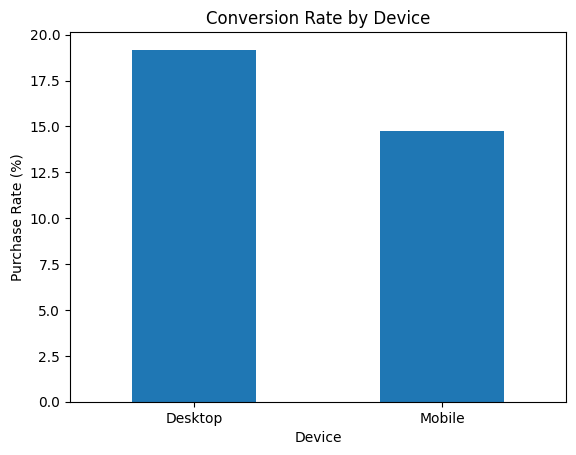

In [ ]:
device_conversion = df.groupby("Device")["Purchase"].mean()*100

device_conversion.plot(kind="bar")

plt.title("Conversion Rate by Device")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)
plt.show()

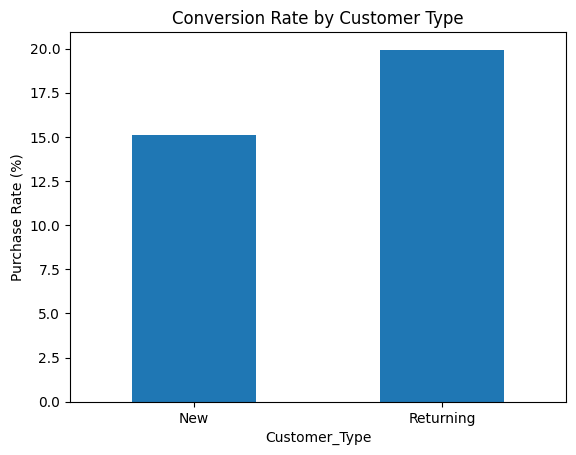

In [ ]:
customer_conversion = df.groupby("Customer_Type")["Purchase"].mean()*100

customer_conversion.plot(kind="bar")

plt.title("Conversion Rate by Customer Type")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)
plt.show()

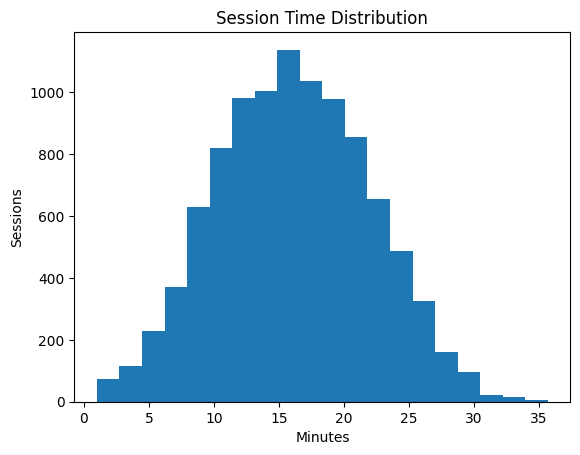

In [ ]:
plt.hist(df["Session_Time"], bins=20)

plt.title("Session Time Distribution")
plt.xlabel("Minutes")
plt.ylabel("Sessions")
plt.show()

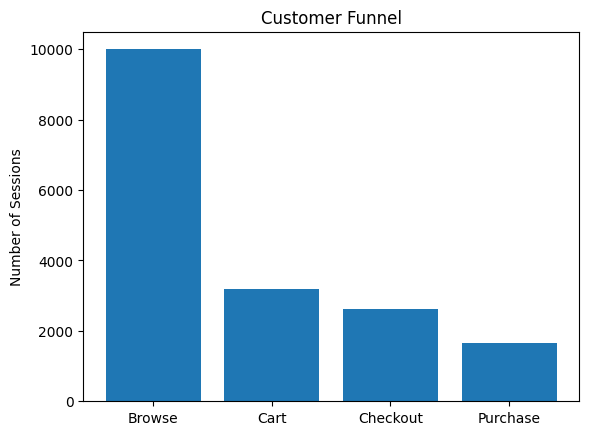

In [ ]:
stages = [
    len(df),
    df["Cart_Added"].sum(),
    df["Checkout_Started"].sum(),
    df["Purchase"].sum()
]

labels = [
    "Browse",
    "Cart",
    "Checkout",
    "Purchase"
]

plt.bar(labels, stages)

plt.title("Customer Funnel")
plt.ylabel("Number of Sessions")
plt.show()

In [ ]:
browse = len(df)
cart = df["Cart_Added"].sum()
checkout = df["Checkout_Started"].sum()
purchase = df["Purchase"].sum()

print("Customer Funnel")
print("----------------")
print("Browse:",browse)
print("Cart:",cart)
print("Checkout:",checkout)
print("Purchase:",purchase)

print("\nConversion Rates")

print("Browse → Cart:",
      round(cart/browse*100,2),"%")

print("Cart → Checkout:",
      round(checkout/cart*100,2),"%")

print("Checkout → Purchase:",
      round(purchase/checkout*100,2),"%")

print("Overall Conversion:",
      round(purchase/browse*100,2),"%")

Customer Funnel
----------------
Browse: 10000
Cart: 3200
Checkout: 2616
Purchase: 1656

Conversion Rates
Browse → Cart: 32.0 %
Cart → Checkout: 81.75 %
Checkout → Purchase: 63.3 %
Overall Conversion: 16.56 %


In [ ]:
comparison = df.groupby("Device").agg({
    "Cart_Added":"mean",
    "Checkout_Started":"mean",
    "Purchase":"mean"
})*100

comparison = comparison.round(2)

comparison

,Cart_Added,Checkout_Started,Purchase
Device,,,
Desktop,34.93,28.86,19.18
Mobile,29.97,24.29,14.75


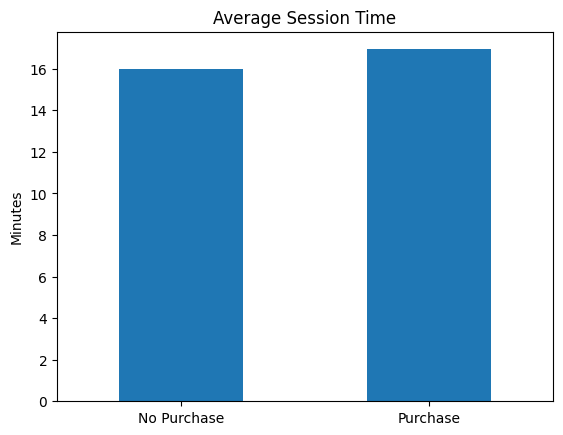

No Purchase    15.991383
Purchase       16.931220
Name: Session_Time, dtype: float64


In [ ]:
avg_time = df.groupby("Purchase")["Session_Time"].mean()

avg_time.index = ["No Purchase","Purchase"]

avg_time.plot(kind="bar")

plt.title("Average Session Time")
plt.ylabel("Minutes")
plt.xticks(rotation=0)
plt.show()

print(avg_time)

In [ ]:
data = df.drop("Session_ID",axis=1)

In [ ]:
encoder = LabelEncoder()

for col in ["Customer_Type","Device","Traffic_Source","Discount_Shown"]:
    data[col] = encoder.fit_transform(data[col])

In [ ]:
X = data.drop("Purchase",axis=1)

y = data["Purchase"]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",round(accuracy*100,2),"%")

Accuracy: 90.35 %


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.89      0.94      1657
           1       0.64      0.98      0.78       343

    accuracy                           0.90      2000
   macro avg       0.82      0.93      0.86      2000
weighted avg       0.93      0.90      0.91      2000



In [ ]:
cm = confusion_matrix(y_test,y_pred)

print(cm)

[[1472  185]
 [   8  335]]


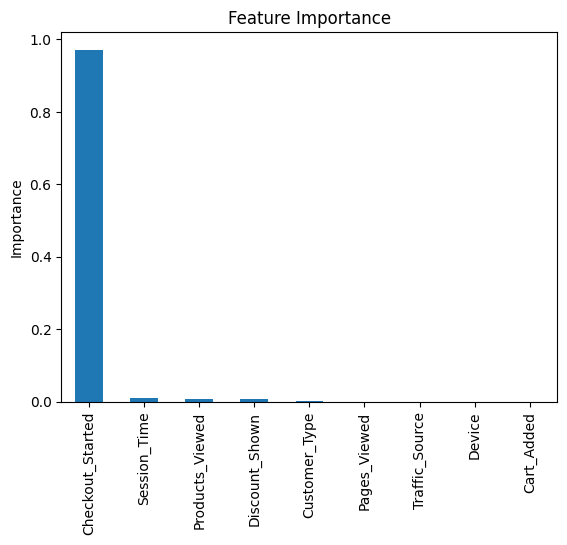

,0
Checkout_Started,0.971320
Session_Time,0.011226
Products_Viewed,0.008421
Discount_Shown,0.007711
Customer_Type,0.001322
Pages_Viewed,0.000000
Traffic_Source,0.000000
Device,0.000000
Cart_Added,0.000000


In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

importance.plot(kind="bar")

plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

importance

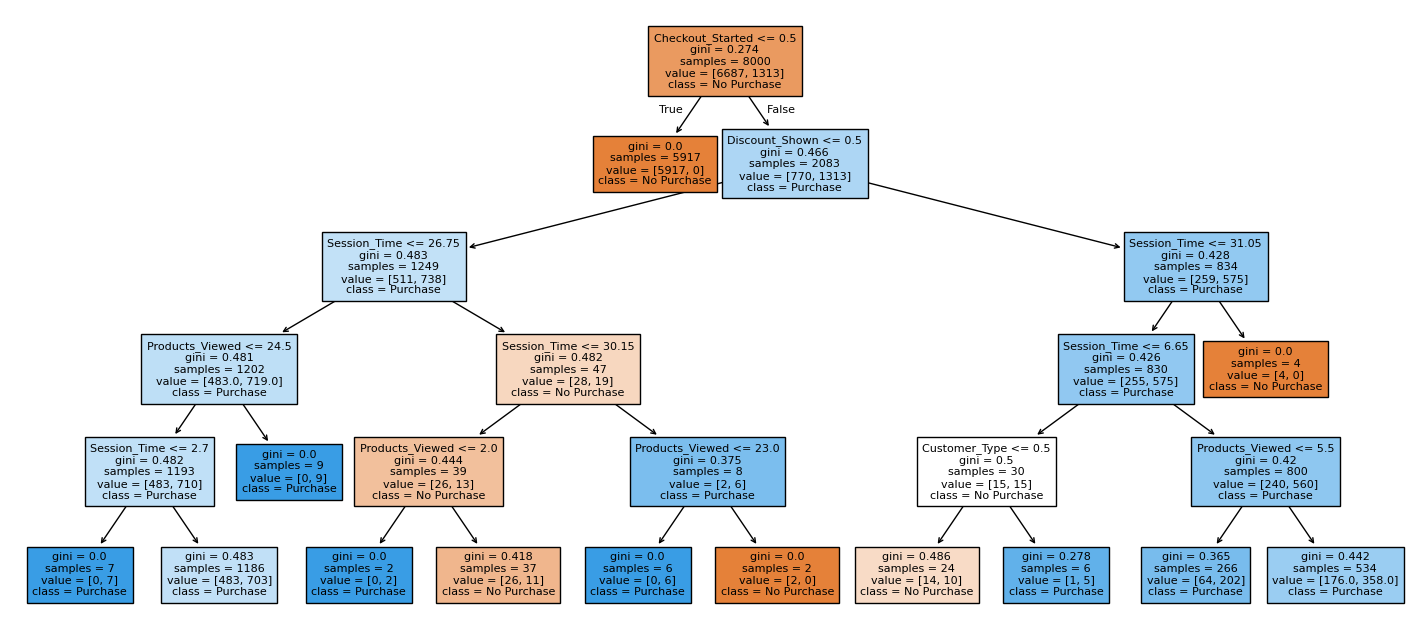

In [ ]:
plt.figure(figsize=(18,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Purchase","Purchase"],
    filled=True,
    fontsize=8
)

plt.show()

In [ ]:
print("Key Insights")
print("------------")

print("1. The biggest customer drop-off occurs between Cart Added and Checkout Started.")

print("2. Desktop users have a higher purchase conversion rate than Mobile users.")

print("3. Returning customers purchase more frequently than New customers.")

print("4. Discounts increase the likelihood of completing a purchase.")

print("5. Longer session time does not always lead to higher purchases.")

print("6. Checkout completion is one of the strongest predictors of purchase.")

print("7. Product engagement influences conversion.")

Key Insights
------------
1. The biggest customer drop-off occurs between Cart Added and Checkout Started.
2. Desktop users have a higher purchase conversion rate than Mobile users.
3. Returning customers purchase more frequently than New customers.
4. Discounts increase the likelihood of completing a purchase.
5. Longer session time does not always lead to higher purchases.
6. Checkout completion is one of the strongest predictors of purchase.
7. Product engagement influences conversion.


In [ ]:
print("Recommended Actions")
print("-------------------")

print("• Simplify the mobile checkout experience.")
print("• Reduce checkout steps.")
print("• Show discounts during checkout.")
print("• Send abandoned-cart reminder emails.")
print("• Improve paid traffic quality.")
print("• Personalize recommendations for returning customers.")

Recommended Actions
-------------------
• Simplify the mobile checkout experience.
• Reduce checkout steps.
• Show discounts during checkout.
• Send abandoned-cart reminder emails.
• Improve paid traffic quality.
• Personalize recommendations for returning customers.
